In [ ]:
!pip install langchain
!pip install langgraph

In [ ]:
from typing import TypedDict

In [ ]:
from langgraph.graph import StateGraph,START,END

In [ ]:
# create a state schema
class Data(TypedDict):
  number1:float
  number2:float
  operator:str
  output:float

NameError: name 'TypedDict' is not defined

In [ ]:
d=Data(number1=10,number2=20,operator="+")

NameError: name 'Data' is not defined

In [ ]:
# create a state graph object which will help us to create / desgin the entire state graph

In [ ]:
graph=StateGraph(state_schema=Data) # we have created a state graph objects which will only allow data as the scehma to flow

In [ ]:
graph.add_node("math_operation",math_operation)

In [ ]:
# crating edges

In [ ]:
graph.add_edge(START,"math_operation")
graph.add_edge("math_operation",END)


In [ ]:
state_graph=graph.compile() #

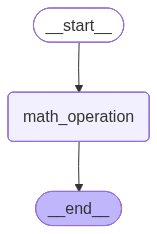

In [ ]:
state_graph

In [ ]:
state_graph.invoke({"number1":10,"number2":20,"operator":"+"})

{'number1': 10, 'number2': 20, 'operator': '+', 'output': 30}

In [ ]:
#

In [ ]:
from array import array

In [ ]:
class Data1(TypedDict):
  imgpath:str
  height:int
  width:int
  output:array

In [ ]:
graph=StateGraph(state_schema=Data1)

In [ ]:
# design two nodes


def resize(state:Data1):
  img=cv2.imread(state["imgpath"])
  img=cv2.resize(img,(state["height"],state["width"]))
  state["output"]=img
  return state

def filter(state:Data1):
  img=cv2.cvtColor(state["output"],cv2.COLOR_BGR2GRAY)

  state["output"]=img
  return state

In [ ]:
graph.add_node("resize",resize)
graph.add_node("filter",filter)

In [ ]:
# add the edges

In [ ]:
graph.add_edge(START,"resize")
graph.add_edge("resize","filter")
graph.add_edge("filter",END)


In [ ]:
state_graph=graph.compile()

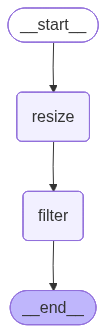

In [ ]:
state_graph

In [ ]:
outhput=state_graph.invoke({"imgpath":"/content/abc1.jpg","height":100,"width":100})

In [ ]:
outhput

{'imgpath': '/content/abc1.jpg',
 'height': 100,
 'width': 100,
 'output': array([[106, 110, 130, ..., 182, 200, 202],
        [131, 153, 170, ..., 177, 194, 196],
        [172, 185, 186, ..., 171, 187, 190],
        ...,
        [203, 202, 186, ..., 250, 252, 253],
        [202, 198, 191, ..., 250, 249, 250],
        [201, 194, 196, ..., 249, 251, 252]], dtype=uint8)}

array([[106, 110, 130, ..., 182, 200, 202],
       [131, 153, 170, ..., 177, 194, 196],
       [172, 185, 186, ..., 171, 187, 190],
       ...,
       [203, 202, 186, ..., 250, 252, 253],
       [202, 198, 191, ..., 250, 249, 250],
       [201, 194, 196, ..., 249, 251, 252]], dtype=uint8)
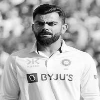

In [ ]:
outhput["output"]